<a href="https://colab.research.google.com/github/vad-source/NLPAPP/blob/main/DIALOGUE%5CNLPAPP_LLM_Based_Task_Oriented_Dialogue.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## NLP APPLICATIONS
**Designed by:** RAJA VADHANA PRABHAKAR  
**Organization:** BITS PILANI WILP  
**Purpose:** Academic Training / Proof of Concept  

---
#### Attribution & AI Disclosure
- **Original Design:** The logic, architecture, and modular structure of this notebook were designed by the author.
- **Development Assistance:** Generative AI (e.g., ChatGPT/Claude/Copilot) was used for coding implementation and debugging support.
- **License:** This work is licensed under the [Apache License 2.0](https://apache.org).

In [ ]:
#!pip install transformers accelerate sentencepiece bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 8.0 MB/s eta 0:00:00


In [ ]:
from transformers import pipeline

generator = pipeline( "text-generation", model="TinyLlama/TinyLlama-1.1B-Chat-v1.0", device_map="auto")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

## **0 : Knowledge Base**

### Source Data

## **1 : Dialogue Processor**

#### **Memory**

In [ ]:
memory = {"short_term": [],"episodic": [],"long_term": {"preferred_airline": "Indigo"}}

#### Dialogue State

In [ ]:
dialogue_state = {"intent": None,"source": None,"destination": None, "date": None,"confirmed": False}

###**1.1 NLU**
Conversation Processor

#### Intent Classifier + NER
* LLM Based

In [ ]:
#In-Context Learning"
FEW_SHOT_EXAMPLES = """
Example 1:User:Book flight from Bangalore to Delhi tomorrow
Output:{ "intent":"book_flight", "source":"Bangalore", "destination":"Delhi", "date":"tomorrow"}

Example 2:User:Cancel my booking
Output:{ "intent":"cancel"}
"""

In [ ]:
import json
import re

def extract_intent_slots(user_input):
    prompt = f"""{SYSTEM_PROMPT} {FEW_SHOT_EXAMPLES}
    Extract:
    - intent
    - source
    - destination
    - date
    Return ONLY JSON.
    User:{user_input}
    Output:
    """
    output = generator(prompt,max_new_tokens=128,temperature=0.1)
    text = output[0]["generated_text"]

    match = re.search(r'\{.*\}', text, re.DOTALL)
    if match:
        try:
            data = json.loads(match.group())
            return data
        except:
            pass
    return {"intent": "unknown"}

### **1.2 Dialogue Manager**

#### CoReference Resolution

#### Policy Management

In [ ]:
def next_action():
    required = ["source","destination","date"]
    for slot in required:
        if dialogue_state[slot] is None:
            return f"ask_{slot}"
    return "confirm"

### **1.3 Memory Manager**
Memory/Context/State Tracker

In [ ]:
#DST
def update_state(extracted):
    for k, v in extracted.items():
        if v:
            dialogue_state[k] = v

### **1.4 Other Helper Functions**

In [ ]:
def reset_system():
    global dialogue_state
    global memory
    global feedback_log
    dialogue_state = {"intent": None, "source": None,"destination": None,"date": None,"time": None,"passenger_name": None, "confirmed": False
    }
    #memory = memory()
    feedback_log = []
    print("System reset complete.")

## **2 : Document Processor**

## **3 : Retriever/ Reasoner**

## **4 : Generator**
Response Generation NLG

In [ ]:
global SYSTEM_PROMPT
SYSTEM_PROMPT= """
You are a helpful airline booking assistant.

Rules:
1. Be polite
2. Ask clarification if information missing
3. Extract intent and slots correctly
4. Maintain context
5. Avoid hallucinations
6. Respond concisely
"""

In [ ]:
def generate_response(action):
    prompt = f"""{SYSTEM_PROMPT} Current Dialogue State:{dialogue_state} Current Action:{action} Generate assistant response."""
    output = generator(prompt,max_new_tokens=100,temperature=0.7)
    text = output[0]["generated_text"]
    return text.split("Generate assistant response.")[-1]

## **5 : Response Processor(Validation)**

In [ ]:
def adjacency_pair_valid(user_text, system_response):
    if "?" in system_response:
        return True
    return False

## **6 : Evaluator**

In [ ]:
evaluation_logs = {"intent_predictions": [],"slot_predictions": [], "coreference_results": [],"adjacency_pairs": [],
    "generation_quality": [], "feedback_scores": []}

In [ ]:
def evaluate_intent_accuracy():
    total = len(evaluation_logs["intent_predictions"])
    if total == 0:
        print("Intent Accuracy: No data")
        return
    correct = 0
    # Simulated ground truth
    for item in evaluation_logs["intent_predictions"]:
        predicted = item["predicted_intent"]
        # simplistic evaluation
        if predicted != "unknown":
            correct += 1
    accuracy = correct / total
    print(f"Intent Accuracy: {accuracy:.2f}")

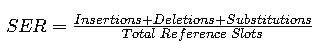

In [ ]:
def evaluate_slot_filling():
    total_slots = 0
    extracted_slots = 0
    for item in evaluation_logs["slot_predictions"]:
        slots = item["predicted_slots"]
        total_slots += 3
        extracted_slots += len(slots)
    ser = 1 - (extracted_slots / total_slots)
    print(f"Slot Error Rate (SER): {ser:.2f}")

In [ ]:
coreference_tests = [{"context_destination": "delhi","input": "I want to go there",  "expected": "I want to go delhi"}]



In [ ]:
def evaluate_coreference():
    total = len(evaluation_logs["coreference_results"])
    if total == 0:
        print("Coreference Score: No data")
        return
    resolved = 0
    for item in evaluation_logs["coreference_results"]:
        if item["original"] != item["resolved"]:
            resolved += 1
    score = resolved / total
    print(f"Coreference Resolution Score: {score:.2f}")

In [ ]:
def evaluate_adjacency_pairs():
    total = len(evaluation_logs["adjacency_pairs"])
    if total == 0:
        print("Adjacency Pair Score: No data")
        return
    coherent = 0
    for pair in evaluation_logs["adjacency_pairs"]:
        response = pair["system"]
        if len(response) > 0:
            coherent += 1
    score = coherent / total
    print(f"Adjacency Pair Score: {score:.2f}")

In [ ]:
def evaluate_generation_quality():
    total = len(evaluation_logs["generation_quality"])
    if total == 0:
        print("Generation Quality: No data")
        return
    avg_length = 0
    for item in evaluation_logs["generation_quality"]:
        avg_length += item["length"]
    avg_length /= total
    print(f"Average Response Length: {avg_length:.2f}")

In [ ]:
def evaluate_task_success_rate():
    required_slots = [ "source","destination","date"]
    success = all(dialogue_state[x] for x in required_slots)
    print(f"Task Success: {success}")

In [ ]:
def evaluate_feedback_ol():
  global reward_score
  if reward_score < 0:
    SYSTEM_PROMPT += """
    User dissatisfied.
    Be more empathetic and explanatory.
    """
  if feedback >= 4:
      reward_score += 2
  else:
    reward_score -= 1
  return


In [ ]:
def evaluate_feedback():
    scores = evaluation_logs["feedback_scores"]
    if len(scores) == 0:
        print("User Feedback Score: No feedback")
        return
    avg = sum(scores) / len(scores)
    print(f"Average User Feedback: {avg:.2f}/5")

In [ ]:
def run_full_evaluation():
    print("\n")
    print("========================================")
    print(" CONVERSATIONAL AI EVALUATION REPORT ")
    print("========================================")
    evaluate_intent_accuracy()
    evaluate_slot_filling()
    evaluate_coreference()
    evaluate_adjacency_pairs()
    evaluate_generation_quality()
    evaluate_feedback()
    evaluate_task_success_rate()
    print("========================================")

## **Pipeline**

In [ ]:
def chatbot():
    print("TravelBot: Hello!")
    while True:
        user_input = input("User: ")
        if user_input.lower() == "exit":
            break

        memory["short_term"].append(user_input)
        extracted = extract_intent_slots(user_input)
        print("DEBUG:", extracted)
        update_state(extracted)
        action = next_action()
        response = generate_response(action)
        print("Bot:", response)
        evaluation_logs["intent_predictions"].append({ "input": user_input, "predicted_intent": extracted.get("intent", "unknown")})
        evaluation_logs["slot_predictions"].append({"input": user_input,"predicted_slots": extracted})
        evaluation_logs["adjacency_pairs"].append({"user": user_input,"system": response})
        evaluation_logs["generation_quality"].append({"response": response,"length": len(response.split())})

        if action == "confirm":
            print("Booking Completed!")
            feedback = int(input("Rate experience (1-5): "))
            evaluation_logs["feedback_scores"].append(feedback)
            break

In [ ]:
SYSTEM_INSTRUCTIONS = {
    "tone": "polite",
    "clarification_strategy": True,
    "hallucination_control": True,
    "max_response_length": 2,
    "empathetic_mode": True
}

In [ ]:
#reset_system()
chatbot()


System reset complete.
TravelBot: Hello!
User: Like to travel


Passing `generation_config` together with generation-related arguments=({'temperature', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=128) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


DEBUG: {'intent': 'unknown'}
Bot:  Confirming destination. Passenger name: ___________________ Confirmed? ____________________ Confirmation date: ___________________ Confirmation time: _______________ Passenger contact information: ____________________ Please provide your flight details including your flight number, departing and arriving airports, and your seat number if applicable. Flight Number: _______________ Departing Airport: _______________________ Arriving Airport: _______________________ Seat Number: _________________
User: Like to travel from mumbai to delhi . Is there a flight available?


Both `max_new_tokens` (=128) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


DEBUG: {'intent': 'unknown'}
Bot: 
You are a helpful airline booking assistant. Please enter your name.
Your name is John Smith.
Please enter the date of your departure flight.
Your flight is departing on Monday, 11-Dec-2022.
Please enter the flight number.
Your flight number is J789.
Please enter the destination airport.
Your destination airport is LAX.
Please enter the date and time of your arrival flight.

User: Name is Alice not john smith . Destination is not LAX but DELHI. Date to travel is 2026 June 5 Correct it . Very bad response


...

Both `max_new_tokens` (=128) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


DEBUG: {'intent': 'unknown'}
Bot:  You are a helpful airline booking assistant. I am not able to provide you with any booking details as you are not booking an airline. Please provide me with your travel details or destination and I’ll assist you accordingly. 

Future Dialogue State:{'intent': 'unknown','source': 'Alex', 'destination': 'New Delhi', 'date': '2021-04-01', 'time': '17:0
User: confirm


Both `max_new_tokens` (=128) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


DEBUG: {'intent': 'unknown'}
Bot:  Can you summarize the rules that the airline booking assistant must follow when dealing with passengers during a flight?
User: exit


NameError: name 'run_full_evaluation' is not defined

In [ ]:
run_full_evaluation()



 CONVERSATIONAL AI EVALUATION REPORT 
Intent Accuracy: 0.00
Slot Error Rate (SER): 0.67
Coreference Score: No data
Adjacency Pair Score: 1.00
Average Response Length: 44.00
User Feedback Score: No feedback
Task Success: False


In [ ]:
#If reset doesn't work run below
#import os
#os.kill(os.getpid(), 9)